In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow
import matplotlib.pyplot as plt
from PIL import Image
import matplotlib.pyplot as plt

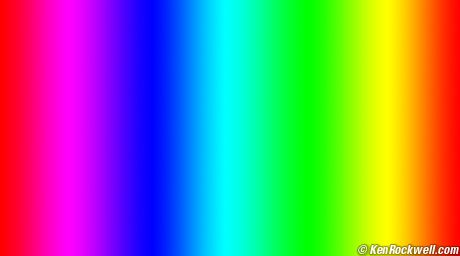

In [252]:
my_img = cv2.imread('drive/My Drive/rgb.jpg')
cv2_imshow(my_img)
#plt.imshow(my_img, cmap="gray")

In [253]:
x, y = my_img.shape[:2]
x, y = my_img.shape[:2]
print(f"Width: {x}, Height: {y}")

Width: 256, Height: 460


RSA


In [254]:
#RSA

# STEP 1: Generate Two Large Prime Numbers (p,q) randomly
from random import randrange, getrandbits


def power(a,d,n):
  ans=1;
  while d!=0:
    if d%2==1:
      ans=((ans%n)*(a%n))%n
    a=((a%n)*(a%n))%n
    d>>=1
  return ans;

def MillerRabin(N,d):
  a = randrange(2, N - 1)
  x=power(a,d,N);
  if x==1 or x==N-1:
    return True;
  else:
    while(d!=N-1):
      x=((x%N)*(x%N))%N;
      if x==1:
        return False;
      if x==N-1:
        return True;
      d<<=1;
  return False;

def is_prime(N,K):
  if N==3 or N==2:
    return True;
  if N<=1 or N%2==0:
    return False;

  #Find d such that d*(2^r)=X-1
  d=N-1
  while d%2!=0:
    d/=2;

  for _ in range(K):
    if not MillerRabin(N,d):
      return False;
  return True;


def generate_prime_candidate(length):
  # generate random bits
  p = getrandbits(length)
  # apply a mask to set MSB and LSB to 1
  # Set MSB to 1 to make sure we have a Number of 1024 bits.
  # Set LSB to 1 to make sure we get a Odd Number.
  p |= (1 << length - 1) | 1
  return p

def generatePrimeNumber(length):
  A=4
  while not is_prime(A, 128):
        A = generate_prime_candidate(length)
  return A
length=5
P=generatePrimeNumber(length)
Q=generatePrimeNumber(length)

print(P)
print(Q)

29
31


In [255]:
#Step 2: Calculate N=P*Q and Euler Totient Function = (P-1)*(Q-1)
N=P*Q
eulerTotient=(P-1)*(Q-1)
print(N)
print(eulerTotient)

899
840


In [256]:
#Step 3: Find E such that GCD(E,eulerTotient)=1(i.e., e should be co-prime) such that it satisfies this condition:-  1<E<eulerTotient

def GCD(a,b):
  if a==0:
    return b;
  return GCD(b%a,a)

E=generatePrimeNumber(4)
while GCD(E,eulerTotient)!=1:
  E=generatePrimeNumber(4)
print(E)


13


In [257]:
# Step 4: Find D.
#For Finding D: It must satisfies this property:-  (D*E)Mod(eulerTotient)=1;
#Now we have two Choices
# 1. That we randomly choose D and check which condition is satisfying above condition.
# 2. For Finding D we can Use Extended Euclidean Algorithm: ax+by=1 i.e., eulerTotient(x)+E(y)=GCD(eulerTotient,e)
#Here, Best approach is to go for option 2.( Extended Euclidean Algorithm.)

def gcdExtended(E,eulerTotient):
  a1,a2,b1,b2,d1,d2=1,0,0,1,eulerTotient,E

  while d2!=1:

    # k
    k=(d1//d2)

    #a
    temp=a2
    a2=a1-(a2*k)
    a1=temp

    #b
    temp=b2
    b2=b1-(b2*k)
    b1=temp

    #d
    temp=d2
    d2=d1-(d2*k)
    d1=temp

    D=b2

  if D>eulerTotient:
    D=D%eulerTotient
  elif D<0:
    D=D+eulerTotient

  return D


D=gcdExtended(E,eulerTotient)
print(D)

517


In [258]:
row,col=my_img.shape[0],my_img.shape[1]
enc = [[0 for x in range(3000)] for y in range(3000)]

In [259]:
import time

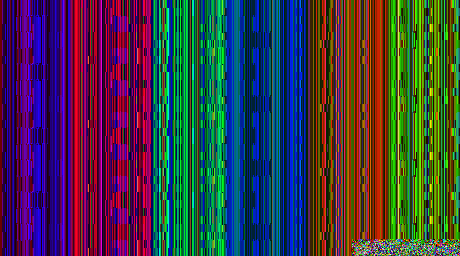


After RSA encryption:

Time: 0 min 0sec


In [260]:
#Step 5: Encryption
start = time.time()
end = time.time()
t = end - start
m = int(t // 60)
s = int(t % 60)
for i in range (my_img.shape[0]):
  for j in range (my_img.shape[1]):
    r,g,b=my_img[i,j]
    C1=power(r,E,N)
    C2=power(g,E,N)
    C3=power(b,E,N)
    enc[i][j]=[C1,C2,C3]
    C1=C1%256
    C2=C2%256
    C3=C3%256
    my_img[i,j]=[C1,C2,C3]


# plt.imshow(my_img, cmap="gray")
cv2_imshow(my_img)
print("\nAfter RSA encryption:\n")
print(f"Time: {m} min {s}sec")

ECC

In [261]:
#initialising all the values for ECC encryption
bit = []
g = 360
na = 1905302 #private key for user a
nb = 1905215 #private key for a user b
pa = na*g #public key for user a
pb = nb*g #public key for user b
k=na*pb #calculation of secret key  (same for both)
ex = k*g #to derive a secret key between 2 parties for secure communication

In [262]:
#Converting image into 1D array, defining sval and adding sval to each of the pixels

import time
time.sleep(1)
i = np.array(my_img)
arr=i.ravel()
sz = x*y*3
arr  = np.reshape(i,sz)
sval  = arr[100]
arr1 = arr + sval

In [263]:
def reimg(px, x, y):  # Converts pixel values to image
    size = (x, y, 3)
    newarray = np.reshape(px, size)
    plt.savefig('newarray')
    plt.imshow(newarray)

In [264]:
def ecc_enc(cipher, n):  # ECC array Encryption
    exa = []
    eya = []
    for vi in range(0, n):
        pm = cipher[vi]
        ex = k * g
        ey = pm + k * pb
        exa.append(ex)
        eya.append(ey)
    ret = exa + eya
    return ret

def ecc_dec(code, n):  # ECC array Decryption
    dx = []
    for vi in range(0, n):
        s1 = code[vi] * nb  # code[vi] = x
        store = code[n + vi] - s1  # code[len(code)/2 + vi] = y
        dx.append(store)
    return dx

In [277]:
# ECC encryption
start = time.time()
ee = ecc_enc(arr1, len(arr))
end = time.time()
t = end - start
m = int(t // 60)
s = int(t % 60)
print(ee[:5])
print("\nAfter ECC encryption:\n")
print(f"Time: {m} min {s}sec")

[61419768352815600, 61419768352815600, 61419768352815600, 61419768352815600, 61419768352815600]

After ECC encryption:

Time: 0 min 0sec


In [266]:
def ecc_enc_img(ee, sz, x, y):  # Encrypting an image with ECC
    e_cipher = ecc_enc(ee, sz)
    img_data = []
    for i in range(0, sz):
        img_data.append(e_cipher[i % 2])
    img_data = np.array(img_data).reshape((x, y, 3))
    img_data = img_data.astype('uint8')
    plt.imsave('encrypted_image.png', img_data)
    plt.imshow(img_data)

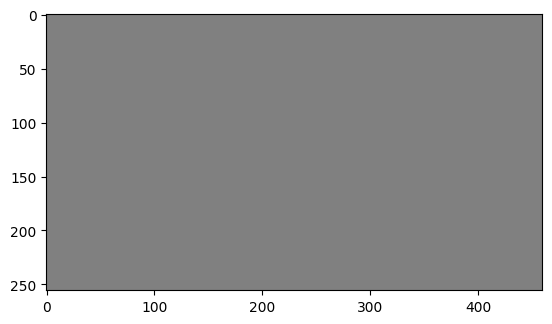

In [267]:
# ECC encrypted image
ecc_enc_img(ee, sz, x, y)


In [268]:
#ECC Decryption

start = time.time()
ed = ecc_dec(ee,int(len(ee)/2))
end = time.time()
t = end - start
m = int(t//60)
s = int(t%60)
print("After ECC Decryption:\n")
print(f"Time: {m} min {s}sec")

After ECC Decryption:

Time: 0 min 0sec


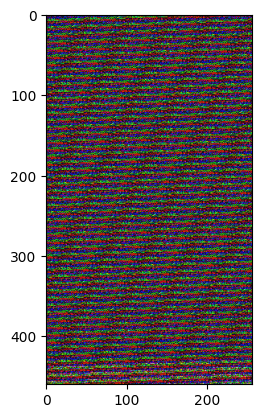

In [269]:
reimg(ed,y,x)


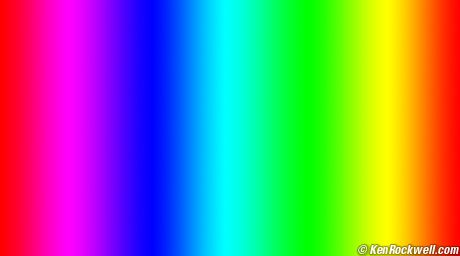


After RSA decryption:

Time: 0 min 0sec


In [270]:
#Step 6: Decryption
start = time.time()
end = time.time()
t = end - start
m = int(t // 60)
s = int(t % 60)
for i in range (my_img.shape[0]):
  for j in range (my_img.shape[1]):
    r,g,b=enc[i][j]
    M1=power(r,D,N)
    M2=power(g,D,N)
    M3=power(b,D,N)
    my_img[i,j]=[M1,M2,M3]

cv2_imshow(my_img)
print("\nAfter RSA decryption:\n")
print(f"Time: {m} min {s}sec")

ACCURACY STUFF


In [271]:
import math
import numpy as np
from PIL import Image

def psnr(img1, img2):
    mse = np.mean((img1 - img2) ** 2)
    if mse == 0:
        return 100
    PIXEL_MAX = 255.0
    return 20 * math.log10(PIXEL_MAX / math.sqrt(mse))

# Convert the encrypted and decrypted images to numpy arrays
img1 = np.array(Image.open('encrypted_image.png'))
img2 = np.array(my_img)

# Select only the first three channels of img1
img1 = img1[:,:,:3]

# Calculate PSNR
psnr_value = psnr(img1, img2)
print(f'PSNR: {psnr_value}')

PSNR: 32.68544127469091


In [272]:
from scipy.stats import entropy
img4 = np.array(Image.open('img4.png'))
def entropy_calc(img):
    hist, bins = np.histogram(img.flatten(), bins=256, range=[0,256])
    return entropy(hist)

# Calculate entropy
entropy_value = entropy_calc(img4)
print(f'Entropy: {entropy_value}')

Entropy: 3.3537813342750717


In [273]:
def entropy(signal):
        '''
        function returns entropy of a signal
        signal must be a 1-D numpy array
        '''
        lensig=signal.size
        symset=list(set(signal))
        numsym=len(symset)
        propab=[np.size(signal[signal==i])/(1.0*lensig) for i in symset]
        ent=np.sum([p*np.log2(1.0/p) for p in propab])
        return ent

In [274]:
colorIm=Image.open('img1.png')
greyIm=colorIm.convert('L')
colorIm=np.array(colorIm)
greyIm=np.array(greyIm)

In [275]:
N=5
S=greyIm.shape
E=np.array(greyIm)
for row in range(S[0]):
        for col in range(S[1]):
                Lx=np.max([0,col-N])
                Ux=np.min([S[1],col+N])
                Ly=np.max([0,row-N])
                Uy=np.min([S[0],row+N])
                region=greyIm[Ly:Uy,Lx:Ux].flatten()
                E[row,col]=entropy(region)

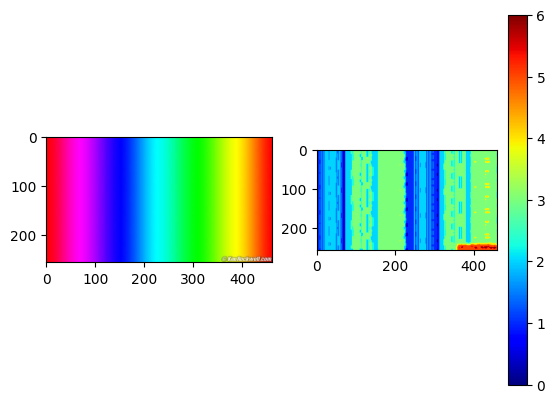

In [276]:
plt.subplot(1,2,1)
plt.imshow(colorIm)

#plt.subplot(1,3,2)
#plt.imshow(greyIm, cmap=plt.cm.gray)

plt.subplot(1,2,2)
plt.imshow(E, cmap=plt.cm.jet)
#plt.xlabel('Entropy in 10x10 neighbourhood')
plt.colorbar()

plt.show()